# Espressività del PMA per il trimero ad anello — RBS vs $W$, indagine da zero

**Ruolo di questo notebook.** Stesso ruolo di `analisi_rotazioni_PMA.ipynb` per il
dimero: un'indagine mirata che **precede** e informa il confronto sistematico
(`confronto_ansatz_entangler_trimero_anello.ipynb`), non il contrario. Qui non si
presuppone nessun risultato di quel notebook — in particolare, **non si usa nessun
punto di lavoro scoperto da un suo sweep**.

**Due domande.**
1. La domanda "dove mettere le rotazioni che rompono $M$" (1q vs 2q) è già risolta nel
   dimero, topology-indipendente: non viene riaperta qui.
2. Domanda nuova, specifica di questo notebook: **esistono varianti del PMA più
   compatte di quelle basate su RBS, usando il gate $W_{ij}(\theta)$ (mirror diretto
   del PMA "originale" di Crippa et al., già implementato in
   `vqe_trimer_ring_W.py`) al posto di RBS?**

**Punto di lavoro.** $b=b_c=2J+J'=2.4$ per $(J,J')=(1,0.4)$ — il campo critico
**teorico**, noto dalla Fase 1 (`teoria_trimero_isoscele.pdf`), indipendente da
qualunque VQE: stessa logica con cui `analisi_rotazioni_PMA.ipynb` (dimero) usa
$b/J=2=b_c$, il campo critico teorico del dimero, come punto di test. Non è un punto
scoperto da uno sweep.

## 0. Setup

In [1]:
import os, json, time
import numpy as np
from scipy.optimize import minimize
from qiskit.quantum_info import Statevector
from qiskit.circuit import QuantumCircuit, ParameterVector

from trimer_ring_exact import (
    critical_field, ground_state_projector_dm,
)

BOND12, BOND23, BOND31 = (2, 1), (1, 0), (0, 2)
BONDS = [BOND12, BOND23, BOND31]

def rbs_block(qc, phi, q0, q1):
    sub = QuantumCircuit(2, name="RBS")
    sub.h(0); sub.h(1); sub.cz(0, 1)
    sub.ry(phi, 0); sub.ry(-phi, 1)
    sub.cz(0, 1); sub.h(0); sub.h(1)
    qc.append(sub.to_gate(label="RBS"), [q0, q1])

def w_block(qc, theta, q0, q1):
    # mirror diretto di vqe_dimer.py / vqe_trimer_ring_W.py: CNOT-Ry-CNOT,
    # NON l'esponenziale completo W_ij(theta)=exp(-i*theta*s_i.s_j) di Crippa.
    sub = QuantumCircuit(2, name="W")
    sub.cx(0, 1); sub.ry(theta, 0); sub.cx(0, 1)
    qc.append(sub.to_gate(label="W"), [q0, q1])

def pma_1q_trimer(nparam, block):
    p = ParameterVector("p", nparam)
    qc = QuantumCircuit(3)
    qc.x(0)
    i, bond_idx = 0, 0
    block(qc, p[i], *BONDS[bond_idx % 3]); i += 1; bond_idx += 1
    while i < nparam:
        qc.ry(p[i], 0); i += 1
        if i < nparam:
            block(qc, p[i], *BONDS[bond_idx % 3]); i += 1; bond_idx += 1
    return qc

def pma_2q_trimer_exact(nparam, block):
    p = ParameterVector("p", nparam)
    qc = QuantumCircuit(3)
    qc.x(0)
    block(qc, p[0], *BOND12); block(qc, p[1], *BOND23); block(qc, p[2], *BOND31)
    i = 3
    while i < nparam:
        qc.ry(p[i], 0); qc.ry(p[i + 1], 1); qc.ry(p[i + 2], 2)
        i += 3
    return qc

def pma_2q_trimer_cyclic(K, block):
    nparam = 6 * K
    p = ParameterVector("p", nparam)
    qc = QuantumCircuit(3)
    qc.x(0)
    idx = 0
    for _ in range(K):
        block(qc, p[idx], *BOND12); idx += 1
        block(qc, p[idx], *BOND23); idx += 1
        block(qc, p[idx], *BOND31); idx += 1
        qc.ry(p[idx], 0); idx += 1
        qc.ry(p[idx], 1); idx += 1
        qc.ry(p[idx], 2); idx += 1
    return qc

CANDIDATI = {
    "RBS-1q.6":   pma_1q_trimer(6, rbs_block),
    "RBS-1q.9":   pma_1q_trimer(9, rbs_block),
    "RBS-2q.6":   pma_2q_trimer_exact(6, rbs_block),
    "RBS-2q.9":   pma_2q_trimer_exact(9, rbs_block),
    "RBS-2qC.K1": pma_2q_trimer_cyclic(1, rbs_block),
    "W-1q.6":     pma_1q_trimer(6, w_block),
    "W-1q.9":     pma_1q_trimer(9, w_block),
    "W-2q.6":     pma_2q_trimer_exact(6, w_block),
    "W-2q.9":     pma_2q_trimer_exact(9, w_block),
    "W-2qC.K1":   pma_2q_trimer_cyclic(1, w_block),
}
for name, qc in CANDIDATI.items():
    print(f"  {name:12s} {qc.num_parameters} parametri")

CACHE_PATH = "espressivita_anello_cache.json"
def load_cache():
    if os.path.exists(CACHE_PATH):
        with open(CACHE_PATH) as f:
            return json.load(f)
    return {}
def save_cache(c):
    with open(CACHE_PATH, "w") as f:
        json.dump(c, f, indent=1)
cache = load_cache()
print(f"\npunti gia' in cache: {len(cache)}")

  RBS-1q.6     6 parametri
  RBS-1q.9     9 parametri
  RBS-2q.6     6 parametri
  RBS-2q.9     9 parametri
  RBS-2qC.K1   6 parametri
  W-1q.6       6 parametri
  W-1q.9       9 parametri
  W-2q.6       6 parametri
  W-2q.9       9 parametri
  W-2qC.K1     6 parametri

punti gia' in cache: 20


## 1. Costo in gate: RBS vs $W$

Stesso numero di gate a due qubit per blocco (2), ma $W$ non usa Hadamard: il costo
totale (1 qubit + 2 qubit) è molto più basso.

In [2]:
print(f"{'ansatz':12s} {'par':>4s} {'2q-gate':>8s} {'1q-gate':>8s} {'totale':>7s}")
print("-"*44)
for name, qc in CANDIDATI.items():
    ops = qc.decompose().count_ops()
    n_2q = ops.get("cz", 0) + ops.get("cx", 0)
    n_tot = sum(ops.values())
    print(f"{name:12s} {qc.num_parameters:4d} {n_2q:8d} {n_tot-n_2q:8d} {n_tot:7d}")

ansatz        par  2q-gate  1q-gate  totale
--------------------------------------------
RBS-1q.6        6        6       22      28
RBS-1q.9        9       10       35      45
RBS-2q.6        6        6       22      28
RBS-2q.9        9        6       25      31
RBS-2qC.K1      6        6       22      28
W-1q.6          6        6        7      13
W-1q.9          9       10       10      20
W-2q.6          6        6        7      13
W-2q.9          9        6       10      16
W-2qC.K1        6        6        7      13


## 1.5 Selettore interattivo: visualizza un circuito qualsiasi

Menu a tendina per scegliere uno dei 10 ansatz e vederne subito il circuito
disegnato, con conteggio di parametri e gate a due qubit. Se `ipywidgets` non è
installato, la cella successiva mostra invece tutti e 10 i circuiti in sequenza,
senza errori.

Circuito di default (candidato canonico, sez. 6):
W-2q.6 -- 6 parametri, 6 gate a due qubit, 13 gate totali


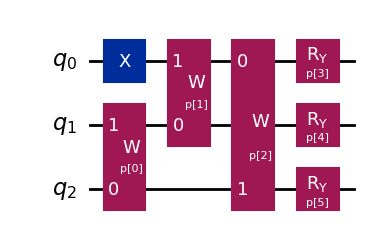


Selettore interattivo (richiede un kernel Jupyter vivo -- non mostra nulla in un viewer statico):


Dropdown(description='Ansatz:', index=7, options=('RBS-1q.6', 'RBS-1q.9', 'RBS-2q.6', 'RBS-2q.9', 'RBS-2qC.K1'…

Output()

In [ ]:
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    HAS_WIDGETS = True
except ImportError:
    HAS_WIDGETS = False

def mostra_circuito(nome):
    qc = CANDIDATI[nome]
    ops = qc.decompose().count_ops()
    n_2q = ops.get("cz", 0) + ops.get("cx", 0)
    print(f"{nome} -- {qc.num_parameters} parametri, {n_2q} gate a due qubit, "
          f"{sum(ops.values())} gate totali")
    try:
        display(qc.draw("mpl", style="iqp"))
    except Exception:
        print(qc.draw())

# Vista statica di partenza -- sempre visibile riaprendo il file, anche senza
# eseguire il selettore interattivo qui sotto.
print("Circuito di default (candidato canonico, sez. 6):")
mostra_circuito("W-2q.6")

if HAS_WIDGETS:
    dropdown = widgets.Dropdown(
        options=list(CANDIDATI.keys()),
        value="W-2q.6",
        description="Ansatz:",
        style={"description_width": "initial"},
    )
    out = widgets.Output()

    def _on_change(change):
        if change["name"] == "value":
            with out:
                clear_output(wait=True)
                mostra_circuito(change["new"])

    dropdown.observe(_on_change, names="value")
    print("\nSelettore interattivo (richiede un kernel Jupyter vivo -- non "
          "mostra nulla in un viewer statico):")
    display(dropdown, out)
    with out:
        mostra_circuito(dropdown.value)
else:
    print("\nipywidgets non disponibile: mostro tutti gli altri circuiti in sequenza.\n")
    for nome in CANDIDATI:
        if nome != "W-2q.6":
            mostra_circuito(nome)
            print()

**Osservazione.** A parità di gate a due qubit (6, per i candidati a 6 parametri),
le varianti $W$ hanno meno della metà dei gate totali (13 contro 28): nessun
Hadamard, un solo $R_y$ per blocco invece di due.

## 2. Espressività a $D=0$ (baseline)

In [4]:
def max_fidelity(qc, P0, n_restarts=20, seed=3):
    def neg_fid(params):
        sv = Statevector(qc.assign_parameters(params)).data
        return -np.real(sv.conj() @ P0 @ sv)
    rng = np.random.default_rng(seed)
    best = 0.0
    for _ in range(n_restarts):
        x0 = rng.uniform(-np.pi, np.pi, qc.num_parameters)
        r = minimize(neg_fid, x0, method="COBYLA", options={"maxiter": 600, "tol": 1e-12})
        r2 = minimize(neg_fid, r.x, method="L-BFGS-B", options={"maxiter": 600, "ftol": 1e-15})
        best = max(best, -r2.fun)
    return best

J, Jp = 1.0, 0.4
bc = critical_field(J, Jp)
print(f"b_c = {bc} (teorico, Fase 1)")

P0_D0, E0, deg0 = ground_state_projector_dm(J, Jp, bc, None, 0.0)
print(f"degenerazione a b=b_c, D=0: {deg0}")

for name, qc in CANDIDATI.items():
    key = f"fid20|D0|{name}"
    if key in cache:
        print(f"  {name:12s}: F = {cache[key]['fidelity']:.6f}  (da cache)")
        continue
    best = max_fidelity(qc, P0_D0, n_restarts=20)
    cache[key] = {"fidelity": best, "n_restarts": 20}
    save_cache(cache)
    print(f"  {name:12s}: F = {best:.6f}")

b_c = 2.4 (teorico, Fase 1)
degenerazione a b=b_c, D=0: 2
  RBS-1q.6    : F = 1.000000  (da cache)
  RBS-1q.9    : F = 1.000000  (da cache)
  RBS-2q.6    : F = 1.000000  (da cache)
  RBS-2q.9    : F = 1.000000  (da cache)
  RBS-2qC.K1  : F = 1.000000  (da cache)
  W-1q.6      : F = 1.000000  (da cache)
  W-1q.9      : F = 1.000000  (da cache)
  W-2q.6      : F = 1.000000  (da cache)
  W-2q.9      : F = 1.000000  (da cache)
  W-2qC.K1    : F = 1.000000  (da cache)


**Tutte le famiglie raggiungono $\mathcal F=1$ esatto a $D=0$**, sia con RBS sia
con $W$: nessuna sorpresa, coerente con la teoria (ground state reale, entrambi i gate
bastano nel caso isotropo).

## 3. Espressività sotto DM (Opzione B, $D=0.15$) — qui emerge la differenza

In [5]:
D = 0.15
P0_DM, E0dm, degdm = ground_state_projector_dm(J, Jp, bc, "B", D)
print(f"degenerazione a b=b_c, DM Opzione B, D={D}: {degdm}")

for name, qc in CANDIDATI.items():
    key = f"fid20|DM|{name}"
    if key in cache:
        print(f"  {name:12s}: F = {cache[key]['fidelity']:.6f}  (da cache)")
        continue
    best = max_fidelity(qc, P0_DM, n_restarts=20)
    cache[key] = {"fidelity": best, "n_restarts": 20}
    save_cache(cache)
    print(f"  {name:12s}: F = {best:.6f}")

degenerazione a b=b_c, DM Opzione B, D=0.15: 1
  RBS-1q.6    : F = 0.999890  (da cache)
  RBS-1q.9    : F = 1.000000  (da cache)
  RBS-2q.6    : F = 0.999911  (da cache)
  RBS-2q.9    : F = 0.999911  (da cache)
  RBS-2qC.K1  : F = 0.999911  (da cache)
  W-1q.6      : F = 0.868245  (da cache)
  W-1q.9      : F = 1.000000  (da cache)
  W-2q.6      : F = 1.000000  (da cache)
  W-2q.9      : F = 1.000000  (da cache)
  W-2qC.K1    : F = 1.000000  (da cache)


## 4. Risultato

| Famiglia | RBS | $W$ |
|---|---|---|
| 1q, 6 par | $0.999890$ | $\mathbf{0.868245}$ (fallisce) |
| 1q, 9 par | $1.000000$ | $1.000000$ |
| 2q, 6 par | $0.999911$ (tetto) | $\mathbf{1.000000}$ (esatto) |
| 2q, 9 par | $0.999911$ (stesso tetto) | $1.000000$ |
| 2qC.K1, 6 par | $0.999911$ (stesso tetto) | $\mathbf{1.000000}$ |

Tre varianti RBS-2q indipendenti (6, 9 parametri, e la versione ciclica) convergono
**esattamente allo stesso valore**, $0.999911$ -- segnale di un vero tetto strutturale,
non di ottimizzazione incompleta (20 restart, ottimizzazione diretta della fidelity).
Le corrispondenti varianti $W$-2q raggiungono invece $\mathcal F=1$ esatto, tutte e
tre, con lo stesso numero di parametri.

## 5. Lettura: $W$ non è "meglio", è meglio *per la famiglia 2q specificamente*

**Risposta alla domanda posta in apertura**: sì, esiste una variante del PMA più
compatta di quella basata su RBS -- $W$-2q, che con soli **6 parametri e 13 gate
totali** (contro i 28 di RBS-2q) raggiunge fidelity **esatta** dove RBS-2q resta
bloccato a un tetto anche a 9 parametri.

**Ma non è un vantaggio universale del gate $W$**: nella famiglia 1q succede
l'opposto. $W$-1q.6 fallisce vistosamente ($\mathcal F=0.868$), molto peggio di
RBS-1q.6 ($\mathcal F=0.9999$) allo stesso punto. Solo a 9 parametri $W$-1q recupera
l'esatto, alla pari con RBS-1q.

**Il pattern che emerge:**
- **1q**: RBS $\succ$ $W$ (RBS più robusto, specialmente a pochi parametri)
- **2q**: $W$ $\succ$ RBS (W esatto anche a 6 parametri, RBS bloccato anche a 9)

Questo suggerisce che il vantaggio o svantaggio di un gate rispetto all'altro dipende
da **come** è inserito nella sequenza di generatori (alternato a rotazioni locali su un
solo qubit, o seguito da rotazioni indipendenti sui tre qubit), non dal gate in
isolamento -- coerente con quanto già osservato per il dimero in
`scelta_ansatz_RBS_vs_W.md`: RBS e $W$ hanno lo stesso potere espressivo sulle
popolazioni ma fase strutturalmente diversa (reale vs immaginaria); qui, combinati con
strutture diverse (1q vs 2q), quella differenza di fase produce interferenze
opposte a seconda della famiglia.

## 6. Candidato canonico per il confronto sistematico

**$W$-2q$\cdot$6** (blocco $W$, un solo giro sui tre legami, poi triple di $R_y$
indipendenti, 6 parametri) è il miglior compromesso trovato in questa indagine:
fidelity esatta sotto DM al campo critico, metà dei gate totali di RBS-2q a parità di
parametri. Andrà confrontato sistematicamente su tutto l'asse $b$ (non solo $b_c$) nel
notebook di confronto -- da qui in avanti, quando serve *un* PMA di riferimento
compatto, sarà questo, non la versione RBS.

**Da verificare nel notebook successivo**: se il vantaggio di $W$-2q si mantiene anche
lontano da $b_c$ e ad altri valori di $D$, o se è specifico di questo punto.